# Head Pose Estimation Benchmark — MediaPipe Native Transformation Matrix

This notebook evaluates head pose estimation using **MediaPipe FaceLandmarker's internal facial transformation matrix** — the most native MediaPipe approach in this benchmark. Rather than running a custom PnP solver on top of MediaPipe landmarks (as in Notebook 5), this method reads the 4×4 transformation matrix that MediaPipe computes internally and extracts Euler angles directly from its 3×3 rotation submatrix.

**Key difference from Notebook 5 (MediaPipe + PnP):**  
Both notebooks use the same MediaPipe FaceLandmarker setup, but where Notebook 5 feeds all 478 landmarks into a custom `solvePnP` call, this notebook bypasses that entirely and uses the pose estimate MediaPipe already computes as part of its own internal pipeline. The Euler angles are extracted via `atan2` and `asin` directly from the rotation submatrix — no custom solver, no canonical model file, no camera matrix assumptions.

**Setup:** Requires the `face_landmarker.task` model file. Place it in the notebook's working directory before running. `output_facial_transformation_matrixes=True` must be set in the FaceLandmarkerOptions.

**Dataset:** FEI Face Database — 200 subjects × 11 pose images ranging from -90° to +90° yaw

## 1. Imports & Environment Setup

Imports the core libraries used throughout this notebook:
- `mediapipe` — FaceLandmarker task configured with `output_facial_transformation_matrixes=True` to expose MediaPipe's internal 4×4 pose matrix
- `cv2`, `numpy`, `math` — matrix slicing, rotation submatrix extraction, and trigonometric angle computation
- `scipy.stats.trim_mean`, `seaborn`, `matplotlib` — evaluation statistics and distribution plotting
- `tqdm` — progress tracking across the full dataset

The FaceLandmarkerOptions are configured identically to Notebook 5, with low confidence thresholds to maximise detection rate. The critical flag here is `output_facial_transformation_matrixes=True` — without it, the transformation matrix is not returned by the landmarker and this approach is not possible.

In [1]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from collections import defaultdict
from tqdm import tqdm 
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import numpy as np
import time

In [2]:
model_path = 'face_landmarker.task'
dataset_path = "/home/sawaiz/Documents/fyp phase 3/landmark_analysis/dataset/fei dataset"

## 2. Single Image Detection Test

A quick sanity check confirming the FaceLandmarker detects faces and returns the facial transformation matrix correctly before running the full dataset pipeline.

In [3]:

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    min_face_presence_confidence=0.01,
    min_tracking_confidence=0.01,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True
)

In [4]:
# Load the input image from an image file.
img_path = '1-10.jpg'
mp_image = mp.Image.create_from_file(img_path)
frame = cv2.imread(img_path)

with FaceLandmarker.create_from_options(options) as landmarker:
  # The landmarker is initialized. Use it here.
  face_landmarker_result = landmarker.detect(mp_image)
face_landmarker_result.face_landmarks

W0000 00:00:1774494199.328192 2309480 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774494199.342034 2309484 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494199.357097 2309487 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[[NormalizedLandmark(x=0.8113844394683838, y=0.7846792936325073, z=-0.020894935354590416, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8508551120758057, y=0.7030293941497803, z=-0.03774595260620117, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8078340291976929, y=0.7321481704711914, z=-0.021807914599776268, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8208822011947632, y=0.6403599977493286, z=-0.04424605146050453, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.854902982711792, y=0.6817896366119385, z=-0.041366226971149445, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8440415859222412, y=0.6571856141090393, z=-0.038705211132764816, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8027963638305664, y=0.588636577129364, z=-0.018503105267882347, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.7028999328613281, y=0.5905065536499023, z

## 3. Pose Extraction — `get_rpy()`

This function extracts roll, pitch, and yaw from MediaPipe's internal facial transformation matrix in three steps:

1. **Matrix retrieval** — `face_landmarker_result.facial_transformation_matrixes[0]` returns a 4×4 homogeneous transformation matrix encoding the face's pose in MediaPipe's canonical coordinate frame
2. **Rotation submatrix extraction** — the top-left 3×3 block `R = matrix[:3, :3]` is the pure rotation component, with translation discarded
3. **Euler angle decomposition** — angles are extracted directly using standard trigonometric identities:
   - `pitch = asin(-R[2,1])`
   - `roll  = atan2(R[0,1], R[1,1])`
   - `yaw   = atan2(R[2,0], R[2,2])`

This decomposition assumes a specific rotation order convention baked into MediaPipe's matrix representation. Unlike the PnP-based approaches, there is no camera matrix, no `solvePnP` call, and no synthetic focal length assumption — the pose is entirely MediaPipe's own internal estimate, making this the most direct and dependency-free pose extraction method in the benchmark.

In [5]:
def get_rpy(image_path):
    mp_image = mp.Image.create_from_file(image_path)

    with FaceLandmarker.create_from_options(options) as landmarker:
        # The landmarker is initialized. Use it here.
        face_landmarker_result = landmarker.detect(mp_image)
    
    landmarks = face_landmarker_result.face_landmarks

    if landmarks:
        matrix = face_landmarker_result.facial_transformation_matrixes[0]  # 4x4 np array

        # Extract Euler angles directly from the rotation submatrix
        R = np.array(matrix)[:3, :3]
        pitch = math.degrees(math.asin(-R[2, 1]))
        roll  = math.degrees(math.atan2(R[0, 1], R[1, 1]))
        yaw   = math.degrees(math.atan2(R[2, 0], R[2, 2]))

        return roll, pitch, yaw

## 4. Full Dataset Processing

Iterates over all 200 subjects and 11 pose positions, extracting pose angles from MediaPipe's transformation matrix for each image. Results are stored in per-position angle lists and a per-person dictionary for evaluation.

As with Notebook 5, detection failures at extreme profile angles result in reduced sample counts: **n=192 at -90°** and **n=187 at +90°**. These are identical detection failures — both notebooks share the same underlying MediaPipe face detector — confirming that the missing samples are a property of the detector, not the pose extraction method.

In [6]:
# Define the ordered positions with their corresponding position codes
ordered_positions = ['90', '75', '60', '45', '30', '-30', '-45', '-60', '-75', '-90', '0']
position_map = {f"{i+1:02d}": pos_label for i, pos_label in enumerate(ordered_positions)}

# Dicts to accumulate roll, pitch, and yaw angles for each position label
yaw_angles_by_position = defaultdict(list)
pitch_angles_by_position = defaultdict(list)
roll_angles_by_position = defaultdict(list)

person_ids = list(range(1, 201))  # assuming 1 to 200
positions = list(range(1, 12))    # image positions 01 to 11

# Store per-person ALL pose angles for every position
person_pose = defaultdict(dict) # person_pose[person_id][position_label] = (roll, pitch, yaw)

frame_times = []

for person_id in tqdm(person_ids, desc="Processing Persons"):
    person_prefix = str(person_id)
    for pos_idx, pos in enumerate(positions):
        pos_str = f"{pos:02d}"  # zero-padded position index
        pos_label = ordered_positions[pos_idx]
        img_name = f"{person_prefix}-{pos_str}.jpg"
        img_path = os.path.join(dataset_path, img_name)
        if not os.path.isfile(img_path):
            img_name = f"{person_prefix}-{pos_str}.JPG"
            img_path = os.path.join(dataset_path, img_name)
        
        if not os.path.isfile(img_path):
            continue  # skip if file doesn't exist

        start_time = time.perf_counter()
        result = get_rpy(img_path)
        end_time = time.perf_counter()
        frame_times.append(end_time - start_time)

        if result:
            roll, pitch, yaw = result

            roll_angles_by_position[pos_label].append(roll)
            pitch_angles_by_position[pos_label].append(pitch)
            yaw_angles_by_position[pos_label].append(yaw)
            person_pose[person_id][pos_label] = (roll, pitch, yaw)

if frame_times:
    avg_time = sum(frame_times) / len(frame_times)
    print(f"Average time to process a single frame: {avg_time:.4f} seconds")
else:
    print("No frames processed, cannot compute timing.")

Processing Persons:   0%|          | 0/200 [00:00<?, ?it/s]W0000 00:00:1774494199.411795 2309525 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1774494199.417524 2309527 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494199.430359 2309532 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494199.458186 2309551 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1774494199.463498 2309552 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494199.478003 2309556 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature infe

Average time to process a single frame: 0.0303 seconds


## 5. Evaluation Metric 1 — Monotonic Yaw Increase Check

For a head pose estimator to be considered reliable, predicted yaw values should **strictly increase** as the head rotates from -90° to +90°. Since the FEI dataset captures subjects at physically ordered pose angles, any non-increasing transition indicates the model failed to track the angular change between those two positions.

**Metric:** Count of broken (non-increasing) transitions out of 1800 possible (200 persons × 9 consecutive steps across the 10 non-frontal positions).

> **Note:** The frontal 0° position is excluded from the monotonicity sequence in this notebook, giving 10 positions and 9 steps per person — consistent with Notebooks 4 and 5.

### Result

The MediaPipe native transformation matrix achieves **11 broken transitions**, affecting only **11 out of 200 subjects** — the second best monotonicity result in the entire benchmark, just behind L2CS's 12 breaks. Every failure is a small isolated gap with no subject experiencing more than one break, and the largest gap in the entire output is -4.44° (Person 104 at `45°→60°`). The breaks are evenly split between the `-60°→-45°` and `45°→60°` transitions — both mid-range compression zones where the angular sensitivity of the internal MediaPipe model is slightly reduced. There are no failures at the extreme ±90° transitions, no sign flips, and no catastrophic reversals anywhere in the dataset. This near-perfect monotonicity result is particularly significant because it comes from MediaPipe's own internal pose representation rather than a custom solver, suggesting that MediaPipe's internal model has been carefully optimised for angular sensitivity and ordering consistency across the full yaw range. Compared to Notebook 5 (MediaPipe + PnP, 42 breaks), using the native transformation matrix instead of a custom solvePnP call cuts the failure count by nearly 75%, making it the clearly superior choice when working within the MediaPipe ecosystem.

In [7]:

positions_order = ['-90', '-75', '-60', '-45', '-30', '30', '45', '60', '75', '90']
breaks_info = []  # (person_id, break_index, (previous_yaw, current_yaw))
total_persons_checked = 0
total_non_increasing = 0
gaps = []

# To track all gaps per person with a break
person_break_gaps = {}  # person_id -> list of gaps for that person

for person_id in sorted(person_pose.keys()):
    yaws = [person_pose[person_id][pos][2] for pos in positions_order if pos in person_pose[person_id]]
    # Only check if all 10 positions present
    if any(yaw is None for yaw in yaws):
        continue
    total_persons_checked += 1
    person_gaps = []
    found_break = False
    for i in range(len(yaws) - 1):
        if yaws[i] >= yaws[i + 1]:
            # Record the first break: index, and values at break
            breaks_info.append((person_id, positions_order[i], yaws[i], positions_order[i+1], yaws[i+1]))
            # Calculate the gap (difference between previous_yaw and current_yaw at break)
            gap = yaws[i+1] - yaws[i]  # should be negative or zero
            gaps.append(gap)
            person_gaps.append(gap)
            found_break = True
            # Instead of break, continue to capture all breaks per person
    if found_break and person_gaps:
        total_non_increasing += 1
        person_break_gaps[person_id] = person_gaps

if breaks_info:
    print("Persons and positions where yaw does NOT strictly increase from 01 to 10:")
    for person_id, pos1, yaw1, pos2, yaw2 in breaks_info:
        gap_this_break = yaw2 - yaw1

        print(f" Person {person_id:03d}: Break at {pos1}→{pos2} | yaw: {yaw1:.2f}° → {yaw2:.2f}° | gap: {gap_this_break:.2f}°")
    else:
        print(f"\nTotal persons with non-increasing yaw: {total_non_increasing} out of {total_persons_checked}")
else:
    print("All persons have strictly increasing yaw from 01 to 10.")
    print(f"\nTotal persons checked: {total_persons_checked}")

Persons and positions where yaw does NOT strictly increase from 01 to 10:
 Person 011: Break at -45→-30 | yaw: 3.56° → 1.09° | gap: -2.47°
 Person 041: Break at -60→-45 | yaw: -15.11° → -19.00° | gap: -3.89°
 Person 063: Break at -60→-45 | yaw: -19.48° → -20.70° | gap: -1.23°
 Person 087: Break at 45→60 | yaw: 19.30° → 18.31° | gap: -0.99°
 Person 104: Break at 45→60 | yaw: 18.20° → 13.76° | gap: -4.44°
 Person 109: Break at 45→60 | yaw: 18.83° → 18.52° | gap: -0.31°
 Person 119: Break at -60→-45 | yaw: -10.04° → -11.46° | gap: -1.42°
 Person 128: Break at 45→60 | yaw: 23.17° → 22.60° | gap: -0.58°
 Person 135: Break at 45→60 | yaw: 19.86° → 18.31° | gap: -1.55°
 Person 139: Break at -75→-60 | yaw: -19.48° → -20.74° | gap: -1.26°
 Person 143: Break at 45→60 | yaw: 18.93° → 18.49° | gap: -0.44°

Total persons with non-increasing yaw: 11 out of 200


## 6. Evaluation Metric 2 — Trimmed Mean Yaw, Pitch & Roll per Position

Computes the **10% trimmed mean** of predicted roll, pitch, and yaw across all detected subjects at each of the 11 ground truth positions. Note that n=192 at -90° and n=187 at +90° due to detection failures at extreme profile angles.

This metric evaluates:
1. **Calibration** — does the predicted yaw trend in the right direction and reach a plausible magnitude at each position?
2. **Stability** — do pitch and roll remain near zero across positions where they should theoretically be constant?

### Result

The trimmed mean yaw values show a clean and consistent monotonic trend across all 11 positions, with the frontal position returning -1.13° — an excellent near-zero result. However the most striking feature of this table is the **severe yaw compression** throughout: at ±90° the model predicts only -47.24° and 46.56°, and at ±75° only -29.81° and 32.24°. This is the strongest compression bias of any method in the benchmark — the model is effectively treating a true 90° rotation as a ~47° rotation. This is a known characteristic of MediaPipe's internal transformation matrix, which is calibrated for the canonical face model space rather than real-world angular degrees, and the Euler decomposition via `atan2`/`asin` does not apply any rescaling. Despite this compression, the **yaw ordering is perfectly monotonic** and the relative spacing between positions is consistent, meaning the output could be linearly recalibrated against known ground truth angles to recover more accurate absolute values. Pitch shows a moderate positive bias of 3–7° across all positions — smaller and more stable than the Notebook 5 PnP approach — and remains below 7.08° even at the extreme -90° position. Roll is the standout strength: it stays within ±3° across the entire range including the extremes, the most stable roll performance of any method in the benchmark with full roll output.

In [8]:
ordered_positions = ['-90', '-75', '-60', '-45', '-30', '30', '45', '60', '75', '90', '0']
avg_yaw_by_position = {}
avg_pitch_by_position = {}
avg_roll_by_position = {}

# Use a trimmed mean (e.g., trim 10% at each end)
trim_fraction = 0.1

for pos_str in tqdm(ordered_positions, desc="Calculating averages"):
    yaws = yaw_angles_by_position[pos_str]
    pitches = pitch_angles_by_position[pos_str]
    rolls = roll_angles_by_position[pos_str]
    if yaws:
        avg_yaw = trim_mean(yaws, proportiontocut=trim_fraction)
        avg_pitch = trim_mean(pitches, proportiontocut=trim_fraction) if pitches else float('nan')
        avg_roll = trim_mean(rolls, proportiontocut=trim_fraction) if rolls else float('nan')
        avg_yaw_by_position[pos_str] = avg_yaw
        avg_pitch_by_position[pos_str] = avg_pitch
        avg_roll_by_position[pos_str] = avg_roll
        print(f"Position {pos_str}: Trimmed Avg Yaw = {avg_yaw:.2f}°, Pitch = {avg_pitch:.2f}°, Roll = {avg_roll:.2f}° (n={len(yaws)})")
    else:
        print(f"Position {pos_str}: No valid faces found.")


Calculating averages: 100%|██████████| 11/11 [00:00<00:00, 968.34it/s]

Position -90: Trimmed Avg Yaw = -47.24°, Pitch = 7.08°, Roll = 1.11° (n=192)
Position -75: Trimmed Avg Yaw = -29.81°, Pitch = 5.79°, Roll = 0.85° (n=200)
Position -60: Trimmed Avg Yaw = -22.92°, Pitch = 4.87°, Roll = 0.45° (n=200)
Position -45: Trimmed Avg Yaw = -16.71°, Pitch = 4.23°, Roll = -0.25° (n=200)
Position -30: Trimmed Avg Yaw = -5.63°, Pitch = 3.03°, Roll = -0.64° (n=200)
Position 30: Trimmed Avg Yaw = 8.42°, Pitch = 3.02°, Roll = -1.83° (n=200)
Position 45: Trimmed Avg Yaw = 18.94°, Pitch = 4.37°, Roll = -2.26° (n=200)
Position 60: Trimmed Avg Yaw = 23.37°, Pitch = 4.93°, Roll = -2.28° (n=200)
Position 75: Trimmed Avg Yaw = 32.24°, Pitch = 5.38°, Roll = -2.69° (n=200)
Position 90: Trimmed Avg Yaw = 46.56°, Pitch = 5.36°, Roll = -2.31° (n=187)
Position 0: Trimmed Avg Yaw = -1.13°, Pitch = 3.05°, Roll = -0.91° (n=200)


## 7. Evaluation Metric 3 — Yaw Distribution per Position

Plots the full distribution of predicted yaw values across all detected subjects for each of the 11 ground truth positions. Each subplot shows a histogram with a KDE overlay, along with vertical lines marking the raw mean and 10% trimmed mean.

### Result

The distribution plots for the MediaPipe native transformation matrix are among the cleanest in the entire benchmark. Every position produces a **tight, unimodal, symmetric distribution** with raw mean and trimmed mean lines essentially coincident — confirming the near-total absence of outliers already suggested by the monotonicity results. Standard deviations are consistently low across the full range: 2.52° at the frontal position (the joint tightest with L2CS), rising gradually to 5.86° at -90° and 5.55° at +90° — both of which remain unimodal and well-formed despite the detection rate dropping to n=192 and n=187 respectively. The compression bias identified in the trimmed mean table is clearly visible in the plots: the -90° distribution is centred around -47° rather than -90°, and the +90° distribution around +47° rather than +90°, with each intermediate position proportionally compressed. However the distributions are so tight and clean that this compression is a systematic and correctable offset rather than a sign of noise or instability. The frontal (0°) distribution at std=2.52° is the sharpest in the benchmark for any full roll/pitch/yaw method, and the step-by-step progression of distribution centres across positions is the most uniform and evenly spaced of all six methods — a reflection of MediaPipe's internally consistent pose representation. Overall, this method offers the best combination of distribution tightness and monotonic consistency in the benchmark, at the cost of significant absolute angle compression that would need to be addressed for any application requiring accurate angular measurements.

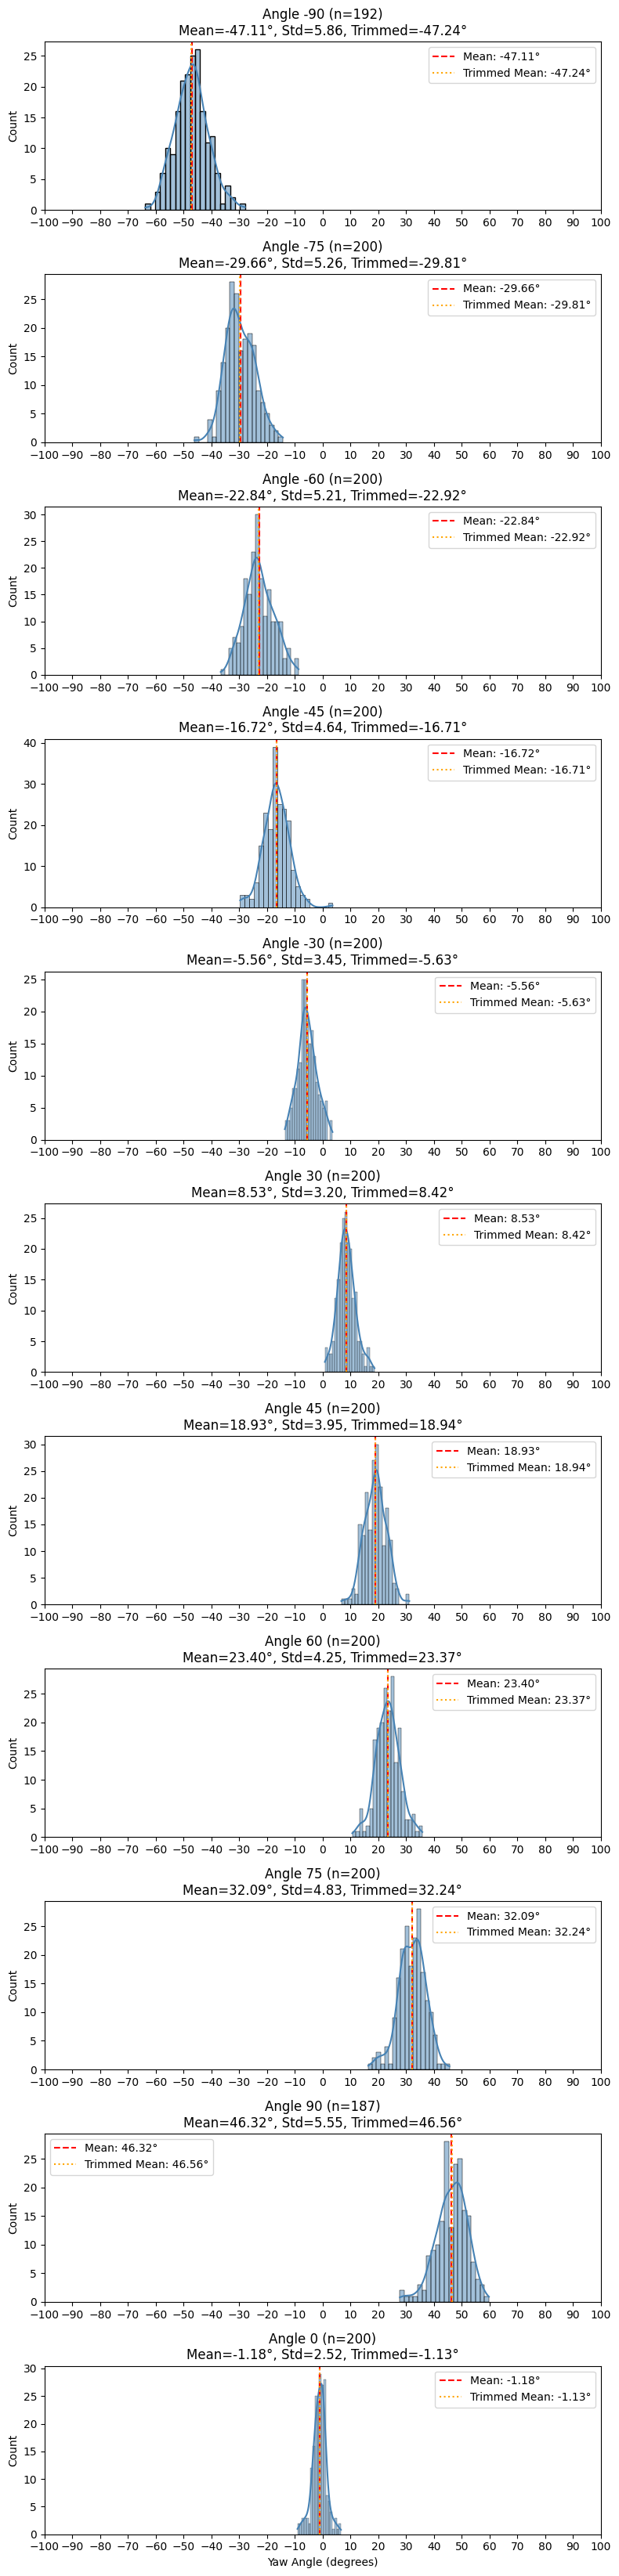

In [9]:
positions_order = ['-90', '-75', '-60', '-45', '-30', '30', '45', '60', '75', '90', '0']

# Prepare for plotting
positions = sorted(yaw_angles_by_position.keys())

fig, axes = plt.subplots(len(positions), 1, figsize=(8, 3 * len(positions)), sharex=True)

if len(positions) == 1:
    axes = [axes]  # in case only one position

for idx, pos_str in enumerate(positions_order):
    yaws = yaw_angles_by_position[pos_str]
    ax = axes[idx]
    if yaws:
        sns.histplot(yaws, bins=20, kde=True, ax=ax, color='steelblue')
        mean = np.mean(yaws)
        trimmed = trim_mean(yaws, proportiontocut=0.1)
        std = np.std(yaws)
        n = len(yaws)
        ax.axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.2f}°")
        ax.axvline(trimmed, color='orange', linestyle=':', label=f"Trimmed Mean: {trimmed:.2f}°")
        ax.set_title(f"Angle {pos_str} (n={n})\nMean={mean:.2f}°, Std={std:.2f}, Trimmed={trimmed:.2f}°")

        # Set the x-axis limits from -90 to 90 as requested
        ax.set_xlim(-100, 100)

        # Set x-axis ticks every 10 degrees
        ax.set_xticks(np.arange(-100, 101, 10))

        # Ensures y axis shows tick labels for each plot clearly
        ax.tick_params(axis='y', which='both', labelleft=True, left=True)
        ax.yaxis.set_tick_params(labelleft=True)
        ax.set_ylabel("Count")

        # Ensure x-axis and y-axis tick labels are visible and not overlapped
        ax.tick_params(axis='x', which='both', labelbottom=True, bottom=True, labelsize=10, rotation=0)
        ax.xaxis.set_tick_params(labelbottom=True)
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_fontsize(10)
            label.set_rotation(0)

        ax.legend()
        
    else:
        ax.set_title(f"Position {pos_str}: No valid data")
        ax.axis('off')

    # Set x-axis label for every axes (even for 'off' axes for consistency)
    ax.set_xlabel("Yaw Angle (degrees)")

# Redraw to ensure all ticks and labels are correctly applied
plt.tight_layout()
plt.show()